# Neural ODE vs ResNet: Classification on MNIST & CIFAR-10

Authors: Rogelio Lozano & Joe Mota

## Section 0 - Setup & Imports

In [1]:
# Install the official ODE solver library from the Neural ODE paper authors
# https://github.com/rtqichen/torchdiffeq
!pip install torchdiffeq --quiet

import torchdiffeq
print(f"torchdiffeq version: {torchdiffeq.__version__}")

torchdiffeq version: 0.2.5


In [2]:
import os
import time
import random
import math
from copy import deepcopy
from collections import defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

from torchdiffeq import odeint, odeint_adjoint

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from tqdm.notebook import tqdm

In [3]:
# Device configuration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Apple MPS backend detected.")
else:
    DEVICE = torch.device("cpu")
    print("No GPU found — running on CPU (training will be slow).")

print(f"\nActive device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

GPU detected: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB

Active device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [4]:
# Global seed for full reproducibility
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seed Python, NumPy, and PyTorch (CPU + CUDA)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)      # multi-GPU safety
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

In [5]:
# All hyperparameters in one place for easy tuning.

CFG = {
    # Training
    "seed":           SEED,
    "batch_size":     128,
    "num_workers":    2,

    # MNIST
    "mnist_epochs":   20,
    "mnist_lr":       1e-3,

    # CIFAR-10
    "cifar_epochs":   60,
    "cifar_lr":       1e-3,

    # ODE solver (torchdiffeq)
    "ode_method":     "dopri5",   # adaptive Runge-Kutta (paper default)
    "ode_rtol":       1e-2,
    "ode_atol":       1e-2,
    "adjoint":        True,       # use adjoint method for memory-efficient backprop

    # Paths
    "data_dir":       "./data",
    "results_dir":    "./results",
}

# Create output directories
os.makedirs(CFG["data_dir"], exist_ok=True)
os.makedirs(CFG["results_dir"], exist_ok=True)

print("Config loaded:")
for k, v in CFG.items():
    print(f"  {k:20} = {v}")

Config loaded:
  seed                 = 42
  batch_size           = 128
  num_workers          = 2
  mnist_epochs         = 20
  mnist_lr             = 0.001
  cifar_epochs         = 60
  cifar_lr             = 0.001
  ode_method           = dopri5
  ode_rtol             = 0.01
  ode_atol             = 0.01
  adjoint              = True
  data_dir             = ./data
  results_dir          = ./results


In [6]:
# Matplotlib

plt.rcParams.update({
    "figure.dpi":         130,
    "figure.facecolor":   "white",
    "axes.facecolor":     "#f8f8f8",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.4,
    "font.size":          11,
    "lines.linewidth":    2.0,
})

# Colour palette used consistently for ResNet vs Neural ODE
PALETTE = {
    "resnet":     "#378ADD",   # blue
    "neural_ode": "#D85A30",   # coral
    "mnist":      "#1D9E75",   # teal
    "cifar":      "#BA7517",   # amber
}

## Section 1 - Datasets Loading & Preprocessing

Loads MNIST and CIFAR-10, applies standard transforms, creates train/val/test DataLoaders, and visualises sample batches. All splits are seeded for reproducibility.

 ### 1.1 - MNIST Loaders

In [7]:
# MNIST
# Input: 1×28×28 grayscale, values normalised to ~N(0,1) using
# dataset mean=0.1307 and std=0.3081 (standard values from literature)

mnist_train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Download once; reuse for val split
mnist_full  = datasets.MNIST(CFG["data_dir"], train=True,  download=True,  transform=mnist_train_tf)
mnist_test  = datasets.MNIST(CFG["data_dir"], train=False, download=True,  transform=mnist_test_tf)

# 55 000 train / 5 000 val split
n_val       = 5_000
n_train     = len(mnist_full) - n_val
mnist_train, mnist_val = random_split(
    mnist_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(CFG["seed"])
)

mnist_loaders = {
    "train": DataLoader(mnist_train, batch_size=CFG["batch_size"], shuffle=True,
                        num_workers=CFG["num_workers"], pin_memory=True),
    "val":   DataLoader(mnist_val,   batch_size=CFG["batch_size"], shuffle=False,
                        num_workers=CFG["num_workers"], pin_memory=True),
    "test":  DataLoader(mnist_test,  batch_size=CFG["batch_size"], shuffle=False,
                        num_workers=CFG["num_workers"], pin_memory=True),
}

print(f"\nMNIST  — train: {n_train:,}  val: {n_val:,}  test: {len(mnist_test):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.92MB/s]


MNIST  — train: 55,000  val: 5,000  test: 10,000


### 1.2 — CIFAR-10 loaders

In [8]:
# ── CIFAR-10
# Input: 3×32×32 RGB.
# Train: random horizontal flip + random crop (standard light augmentation).
# Test/val: only normalise — no augmentation to keep evaluation clean.
# Mean & std are per-channel values computed on the full training set.

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

cifar_train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_full  = datasets.CIFAR10(CFG["data_dir"], train=True,  download=True, transform=cifar_train_tf)
cifar_test  = datasets.CIFAR10(CFG["data_dir"], train=False, download=True, transform=cifar_test_tf)

n_val_c   = 5_000
n_train_c = len(cifar_full) - n_val_c
cifar_train, cifar_val = random_split(
    cifar_full, [n_train_c, n_val_c],
    generator=torch.Generator().manual_seed(CFG["seed"])
)

cifar_loaders = {
    "train": DataLoader(cifar_train, batch_size=CFG["batch_size"], shuffle=True,
                        num_workers=CFG["num_workers"], pin_memory=True),
    "val":   DataLoader(cifar_val,   batch_size=CFG["batch_size"], shuffle=False,
                        num_workers=CFG["num_workers"], pin_memory=True),
    "test":  DataLoader(cifar_test,  batch_size=CFG["batch_size"], shuffle=False,
                        num_workers=CFG["num_workers"], pin_memory=True),
}

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"\nCIFAR-10 — train: {n_train_c:,}  val: {n_val_c:,}  test: {len(cifar_test):,}")


100%|██████████| 170M/170M [07:27<00:00, 381kB/s]



CIFAR-10 — train: 45,000  val: 5,000  test: 10,000


### 1.3 - Dataset Summary

In [9]:
def dataset_summary(name, loaders, n_classes=10):
    """Print a compact summary of a dataset's splits."""
    train_loader = loaders["train"]
    imgs, labels = next(iter(train_loader))
    print(f"\n{'─'*45}")
    print(f" {name}")
    print(f"{'─'*45}")
    print(f"  Input shape  : {tuple(imgs.shape[1:])}")
    print(f"  Classes      : {n_classes}")
    print(f"  Train batches: {len(loaders['train'])}")
    print(f"  Val batches  : {len(loaders['val'])}")
    print(f"  Test batches : {len(loaders['test'])}")

dataset_summary("MNIST",    mnist_loaders)
dataset_summary("CIFAR-10", cifar_loaders)


─────────────────────────────────────────────
 MNIST
─────────────────────────────────────────────
  Input shape  : (1, 28, 28)
  Classes      : 10
  Train batches: 430
  Val batches  : 40
  Test batches : 79

─────────────────────────────────────────────
 CIFAR-10
─────────────────────────────────────────────
  Input shape  : (3, 32, 32)
  Classes      : 10
  Train batches: 352
  Val batches  : 40
  Test batches : 79


### 1.4 - Sample batches Visualization

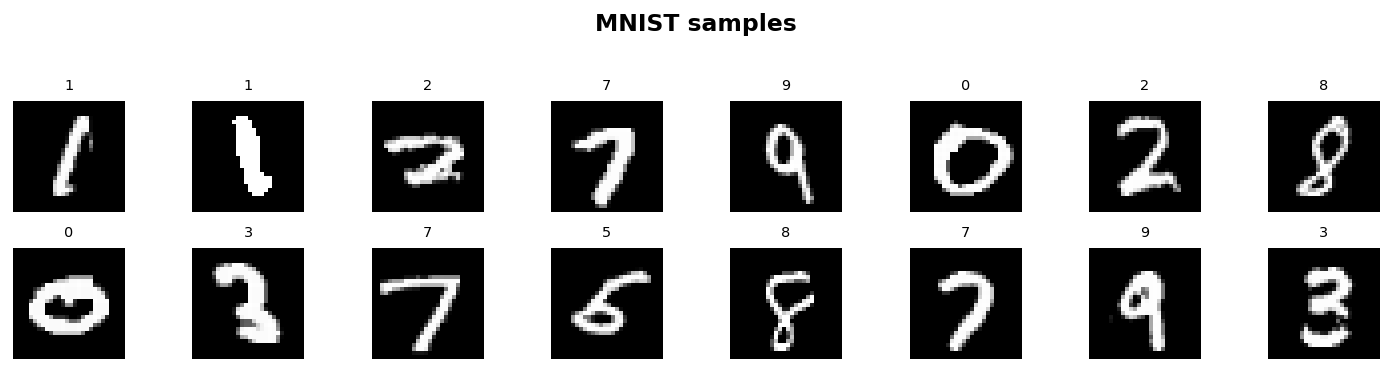

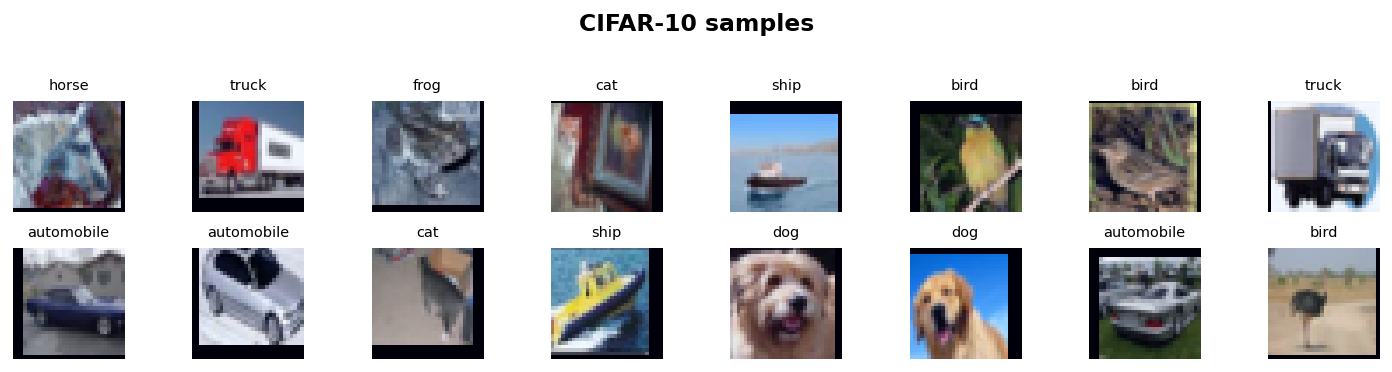

In [10]:
def show_samples(loader, title, n=16, classes=None, cmap=None):
    """Display a grid of n samples from a DataLoader."""
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]

    imgs = imgs - imgs.min()
    imgs = imgs / imgs.max()

    cols = 8
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < n:
            img = imgs[i].permute(1, 2, 0).numpy()
            if img.shape[2] == 1:
                img = img[..., 0]
            ax.imshow(img, cmap=cmap)
            lbl = classes[labels[i]] if classes else str(labels[i].item())
            ax.set_title(lbl, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"{CFG['results_dir']}/{title.lower().replace(' ','_')}_samples.png",
                dpi=130, bbox_inches="tight")
    plt.show()

show_samples(mnist_loaders["train"],  "MNIST samples",    cmap="gray")
show_samples(cifar_loaders["train"],  "CIFAR-10 samples", classes=CIFAR10_CLASSES)

### 1.5 - Label Distribution

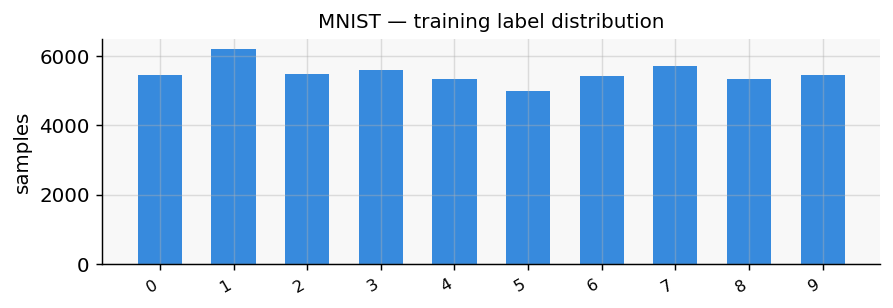

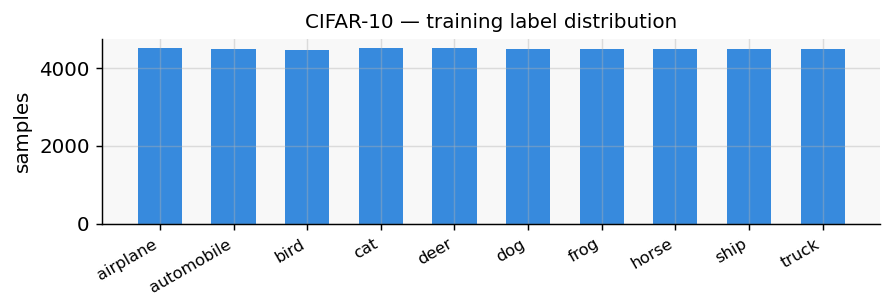

In [11]:
def check_label_balance(loader, name, classes=None):
    """Verify approximate label balance over the full loader."""
    counts = torch.zeros(10, dtype=torch.long)
    for _, labels in loader:
        for l in labels:
            counts[l] += 1

    fig, ax = plt.subplots(figsize=(7, 2.5))
    x = range(10)
    lbls = classes if classes else [str(i) for i in range(10)]
    ax.bar(x, counts.numpy(), color="#378ADD", width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{name} — training label distribution", fontsize=11)
    ax.set_ylabel("samples")
    plt.tight_layout()
    plt.show()

check_label_balance(mnist_loaders["train"],  "MNIST")
check_label_balance(cifar_loaders["train"],  "CIFAR-10", classes=CIFAR10_CLASSES)

## Section 2 - Model Definitions

Defines the ResNet baseline and Neural ODE classifier for both datasets. Parameter counts are matched as closely as possible for a fair comparison.

### 2.1 Shared utilities
A parameter-count helper used throughout this section.

In [12]:
def count_params(model: nn.Module) -> int:
    """Return the total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 2.2 ResNet baseline
A small residual network with 3 stacked ResBlocks. Each block follows the standard conv → BN → ReLU → conv → BN pattern with a skip connection. A final global average pool feeds the classifier head. The number of base channels is tunable so we can match parameter counts against the Neural ODE.

In [13]:
class ResBlock(nn.Module):
    """Standard pre-activation residual block with optional downsampling."""
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class SmallResNet(nn.Module):
    """
    3-stage residual network for MNIST (1-channel) or CIFAR-10 (3-channel).

    Architecture:
        stem  → [stage1: ch×2 blocks] → [stage2: ch*2×2 blocks, stride 2]
              → [stage3: ch*4×2 blocks, stride 2] → GAP → FC(10)
    """
    def __init__(self, in_channels: int = 3, base_ch: int = 16, num_classes: int = 10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.stage1 = self._make_stage(base_ch,      base_ch,      stride=1)
        self.stage2 = self._make_stage(base_ch,      base_ch * 2, stride=2)
        self.stage3 = self._make_stage(base_ch * 2, base_ch * 4, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d((1, 1))
        self.fc     = nn.Linear(base_ch * 4, num_classes)

    def _make_stage(self, in_ch, out_ch, stride):
        return nn.Sequential(
            ResBlock(in_ch,  out_ch, stride=stride),
            ResBlock(out_ch, out_ch, stride=1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

### 2.3 - Neural ODE model
The ODE function f(t, h) is a small conv net. ODEBlock wraps odeint_adjoint (constant-memory backprop from the paper) and tracks NFE — the number of function evaluations the adaptive solver makes per forward pass, a key metric from Chen et al. 2018. The full classifier follows the paper's design: downsample to a feature map, solve the ODE in that space, then pool and classify.

In [14]:
class ODEFunc(nn.Module):
    """
    The dynamics function f(t, h) for the Neural ODE.
    Parameterises dh/dt = f(t, h) with a small conv net.
    Time t is not used directly (autonomous system) but is accepted
    to satisfy the torchdiffeq interface.
    """
    def __init__(self, ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=ch),
            nn.ReLU(inplace=True),
        )
        self.nfe = 0  # number of function evaluations counter

    def forward(self, t, x):
        self.nfe += 1
        return self.net(x)


class ODEBlock(nn.Module):
    """Wraps ODEFunc in a differentiable ODE solve using the adjoint method."""
    def __init__(self, odefunc: ODEFunc):
        super().__init__()
        self.odefunc = odefunc
        # Integration interval t ∈ [0, 1]
        self.integration_time = torch.tensor([0.0, 1.0]).float()

    def forward(self, x):
        self.odefunc.nfe = 0  # reset counter each forward pass
        t = self.integration_time.to(x.device)
        out = odeint_adjoint(
            self.odefunc, x, t,
            method=CFG["ode_method"],
            rtol=CFG["ode_rtol"],
            atol=CFG["ode_atol"],
        )
        return out[1]  # return state at t=1

    @property
    def nfe(self):
        return self.odefunc.nfe


class NeuralODENet(nn.Module):
    """
    Neural ODE classifier for MNIST or CIFAR-10.

    Architecture (mirrors the paper's image classifier design):
        downsample  →  ODEBlock  →  GAP  →  FC(10)

    The downsample block reduces spatial resolution and lifts channels
    so the ODE operates on a compact feature space (cheaper NFE).
    """
    def __init__(self, in_channels: int = 3, ch: int = 64, num_classes: int = 10):
        super().__init__()
        self.downsample = nn.Sequential(
            nn.Conv2d(in_channels, ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 4, stride=2, padding=1, bias=False),  # spatial /2
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 4, stride=2, padding=1, bias=False),  # spatial /4
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
        )
        self.odefunc  = ODEFunc(ch)
        self.odeblock = ODEBlock(self.odefunc)
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.fc       = nn.Linear(ch, num_classes)

    def forward(self, x):
        x = self.downsample(x)
        x = self.odeblock(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

    @property
    def nfe(self):
        """NFE for the most recent forward pass."""
        return self.odeblock.nfe

### 2.4 - Instantiate models & compare parameter counts
Creates one model per dataset per architecture and prints a side-by-side parameter table. Adjust base_ch / ch here to rebalance counts.

In [15]:
# MNIST models (1-channel input)
resnet_mnist   = SmallResNet(in_channels=1, base_ch=16).to(DEVICE)
ode_mnist      = NeuralODENet(in_channels=1, ch=32).to(DEVICE)

# CIFAR-10 models (3-channel input)
resnet_cifar   = SmallResNet(in_channels=3, base_ch=32).to(DEVICE)
ode_cifar      = NeuralODENet(in_channels=3, ch=64).to(DEVICE)

# Parameter count table
rows = [
    ("MNIST",    "ResNet",     count_params(resnet_mnist)),
    ("MNIST",    "Neural ODE", count_params(ode_mnist)),
    ("CIFAR-10", "ResNet",     count_params(resnet_cifar)),
    ("CIFAR-10", "Neural ODE", count_params(ode_cifar)),
]

df_params = pd.DataFrame(rows, columns=["Dataset", "Model", "Trainable params"])
df_params["Trainable params"] = df_params["Trainable params"].apply(lambda n: f"{n:,}")
display(df_params)

,Dataset,Model,Trainable params
0,MNIST,ResNet,"174,970"
1,MNIST,Neural ODE,"52,138"
2,CIFAR-10,ResNet,"696,618"
3,CIFAR-10,Neural ODE,"207,818"


In [16]:
# Verify output shapes with a single dummy batch before any training.
with torch.no_grad():
    dummy_mnist  = torch.randn(4, 1, 28, 28).to(DEVICE)
    dummy_cifar  = torch.randn(4, 3, 32, 32).to(DEVICE)

    assert resnet_mnist(dummy_mnist).shape  == (4, 10), "ResNet MNIST output shape mismatch"
    assert ode_mnist(dummy_mnist).shape     == (4, 10), "ODE MNIST output shape mismatch"
    assert resnet_cifar(dummy_cifar).shape  == (4, 10), "ResNet CIFAR output shape mismatch"
    assert ode_cifar(dummy_cifar).shape     == (4, 10), "ODE CIFAR output shape mismatch"

## Section 3 - Training Infrastructure
Generic train/evaluate functions and a Trainer class reusable across all four experiments. Tracks loss, accuracy, wall-clock time, peak memory, and NFE (Neural ODE only) per epoch.

### 3.1 - train_epoch
One full pass over the training DataLoader. Returns a dict of metrics for that epoch.

In [17]:
def train_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device:    torch.device,
    is_ode:    bool = False,
) -> dict:
    """
    Run one training epoch.

    Returns
    -------
    dict with keys: loss, accuracy, time_s, memory_mb, nfe
         nfe is the mean NFE per batch (0.0 for ResNet).
    """
    model.train()
    total_loss = correct = total = nfe_sum = 0
    t0 = time.perf_counter()

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

        if is_ode:
            nfe_sum += model.nfe

    elapsed = time.perf_counter() - t0
    mem_mb  = (
        torch.cuda.max_memory_allocated(device) / 1e6
        if device.type == "cuda" else 0.0
    )

    return {
        "loss":      total_loss / total,
        "accuracy":  correct / total,
        "time_s":    elapsed,
        "memory_mb": mem_mb,
        "nfe":       nfe_sum / len(loader) if is_ode else 0.0,
    }


### 3.2 - evaluate
Runs inference over any split (val or test) with no gradient tracking. Also captures NFE at inference time for the Neural ODE, which is a separate metric from training NFE.

In [18]:
def evaluate(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    torch.device,
    is_ode:    bool = False,
) -> dict:
    """
    Evaluate model on a DataLoader (val or test).

    Returns
    -------
    dict with keys: loss, accuracy, nfe
    """
    model.eval()
    total_loss = correct = total = nfe_sum = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits     = model(imgs)
            loss       = criterion(logits, labels)

            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)

            if is_ode:
                nfe_sum += model.nfe

    return {
        "loss":     total_loss / total,
        "accuracy": correct / total,
        "nfe":      nfe_sum / len(loader) if is_ode else 0.0,
    }

### 3.3 - Trainer class
Wraps the epoch loop, learning-rate scheduler, best-model checkpointing, and history logging. Call trainer.fit() to run the full experiment; results are stored in trainer.history as a list of per-epoch dicts.

In [19]:
class Trainer:
    """
    Generic trainer for ResNet and Neural ODE experiments.

    Parameters
    ----------
    model      : nn.Module
    loaders    : dict with keys "train", "val", "test"
    epochs     : int
    lr         : float
    device     : torch.device
    is_ode     : bool   — enables NFE tracking
    label      : str    — human-readable name used in saved files
    """
    def __init__(
        self,
        model:   nn.Module,
        loaders: dict,
        epochs:  int,
        lr:      float,
        device:  torch.device,
        is_ode:  bool = False,
        label:   str  = "model",
    ):
        self.model   = model
        self.loaders = loaders
        self.epochs  = epochs
        self.device  = device
        self.is_ode  = is_ode
        self.label   = label

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        # Cosine annealing over full training — smooth LR decay, no tuning needed
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=epochs
        )

        self.history: list[dict] = []
        self.best_val_acc  = 0.0
        self.best_state    = None

    def fit(self) -> list[dict]:
        """Run the full training loop. Returns history."""
        for epoch in range(1, self.epochs + 1):
            train_metrics = train_epoch(
                self.model, self.loaders["train"],
                self.criterion, self.optimizer,
                self.device, self.is_ode,
            )
            val_metrics = evaluate(
                self.model, self.loaders["val"],
                self.criterion, self.device, self.is_ode,
            )
            self.scheduler.step()

            # Checkpoint best model by val accuracy
            if val_metrics["accuracy"] > self.best_val_acc:
                self.best_val_acc = val_metrics["accuracy"]
                self.best_state   = deepcopy(self.model.state_dict())

            record = {
                "epoch":       epoch,
                "train_loss":  train_metrics["loss"],
                "train_acc":   train_metrics["accuracy"],
                "val_loss":    val_metrics["loss"],
                "val_acc":     val_metrics["accuracy"],
                "time_s":      train_metrics["time_s"],
                "memory_mb":   train_metrics["memory_mb"],
                "train_nfe":   train_metrics["nfe"],
                "val_nfe":     val_metrics["nfe"],
            }
            self.history.append(record)

            # Compact per-epoch progress line
            nfe_str = f"  nfe={record['train_nfe']:.1f}" if self.is_ode else ""
            print(
                f"[{self.label}] epoch {epoch:3d}/{self.epochs}"
                f"  train_loss={record['train_loss']:.4f}"
                f"  val_acc={record['val_acc']:.4f}"
                f"  {record['time_s']:.1f}s"
                + nfe_str
            )

        return self.history

    def test(self) -> dict:
        """
        Load the best checkpoint and evaluate on the test set.
        Returns a dict: {loss, accuracy, nfe}.
        """
        self.model.load_state_dict(self.best_state)
        return evaluate(
            self.model, self.loaders["test"],
            self.criterion, self.device, self.is_ode,
        )

    def history_df(self) -> pd.DataFrame:
        """Return training history as a tidy DataFrame."""
        return pd.DataFrame(self.history)

### 3.4 Plotting utilities
Reusable plot functions called in Section 5. Defined here so experiments in Section 4 stay focused on training only.

In [20]:
def plot_loss_curves(histories: dict, dataset_name: str):
    """
    Plot train and val loss curves for all models on a dataset.

    Parameters
    ----------
    histories   : {"ResNet": df, "Neural ODE": df}  — DataFrames from history_df()
    dataset_name: str used in the title and saved filename
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
    split_keys = [("train_loss", "Train loss"), ("val_loss", "Val loss")]

    for ax, (col, title) in zip(axes, split_keys):
        for name, df in histories.items():
            color = PALETTE["resnet"] if "ResNet" in name else PALETTE["neural_ode"]
            ax.plot(df["epoch"], df[col], label=name, color=color)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=9)

    fig.suptitle(f"{dataset_name} - loss curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{CFG['results_dir']}/{dataset_name.lower()}_loss_curves.png",
                dpi=130, bbox_inches="tight")
    plt.show()


def plot_nfe_curve(history_df: pd.DataFrame, dataset_name: str):
    """Plot train and val NFE over epochs for a Neural ODE model."""
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(history_df["epoch"], history_df["train_nfe"],
           label="Train NFE", color=PALETTE["neural_ode"])
    ax.plot(history_df["epoch"], history_df["val_nfe"],
           label="Val NFE", color=PALETTE["neural_ode"], linestyle="--")
    ax.set_title(f"{dataset_name} - Neural ODE function evaluations per batch", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean NFE")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{CFG['results_dir']}/{dataset_name.lower()}_nfe.png",
                dpi=130, bbox_inches="tight")
    plt.show()


def plot_efficiency_bars(summary: dict, dataset_name: str):
    """
    Bar charts for training time and peak memory side-by-side.

    Parameters
    ----------
    summary : {
        "ResNet":     {"time_s": float, "memory_mb": float},
        "Neural ODE": {"time_s": float, "memory_mb": float},
    }
    """
    models  = list(summary.keys())
    colors  = [PALETTE["resnet"], PALETTE["neural_ode"]]
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    for ax, (metric, ylabel) in zip(
        axes,
        [("time_s", "Total training time (s)"), ("memory_mb", "Peak memory (MB)")]
    ):
        vals = [summary[m][metric] for m in models]
        ax.bar(models, vals, color=colors, width=0.4)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel, fontsize=10)
        for i, v in enumerate(vals):
            ax.text(i, v * 1.01, f"{v:.1f}", ha="center", fontsize=9)

    fig.suptitle(f"{dataset_name} — efficiency comparison", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{CFG['results_dir']}/{dataset_name.lower()}_efficiency.png",
                dpi=130, bbox_inches="tight")
    plt.show()


## Section 4 - Experiments
Four training runs in total: ResNet and Neural ODE on MNIST (4.1–4.2), then both on CIFAR-10 (4.3–4.4). Each subsection trains, evaluates, and prints results. Plots are deferred to Section 5.

In [21]:
def print_results(
    label:      str,
    trainer:    Trainer,
    test_metrics: dict,
):
    """
    Print a formatted results block for one experiment.
    Call immediately after trainer.test().

    Parameters
    ----------
    label        : e.g. "ResNet - MNIST"
    trainer      : fitted Trainer instance
    test_metrics : dict returned by trainer.test()
    """
    df      = trainer.history_df()
    total_t = df["time_s"].sum()
    peak_mb = df["memory_mb"].max()
    best_val= trainer.best_val_acc

    sep = "─" * 48
    print(sep)
    print(f" {label}")
    print(sep)
    print(f"  Best val accuracy   : {best_val*100:.2f}%")
    print(f"  Test accuracy       : {test_metrics['accuracy']*100:.2f}%")
    print(f"  Test loss           : {test_metrics['loss']:.4f}")
    print(f"  Total training time : {total_t:.1f}s")
    print(f"  Peak memory (GPU)   : {peak_mb:.1f} MB")
    if trainer.is_ode:
        mean_train_nfe = df["train_nfe"].mean()
        mean_val_nfe   = df["val_nfe"].mean()
        final_nfe      = df["train_nfe"].iloc[-1]
        print(f"  Mean train NFE/batch: {mean_train_nfe:.1f}")
        print(f"  Mean val NFE/batch  : {mean_val_nfe:.1f}")
        print(f"  Final epoch NFE     : {final_nfe:.1f}")
        print(f"  Test NFE/batch      : {test_metrics['nfe']:.1f}")
    print(sep)

### 4.1 - ResNet on MNIST
Trains the small ResNet baseline on MNIST for CFG["mnist_epochs"] epochs. Best checkpoint is saved internally by the Trainer.

In [22]:
set_seed(CFG["seed"])

resnet_mnist = SmallResNet(in_channels=1, base_ch=16).to(DEVICE)

trainer_resnet_mnist = Trainer(
    model   = resnet_mnist,
    loaders = mnist_loaders,
    epochs  = CFG["mnist_epochs"],
    lr      = CFG["mnist_lr"],
    device  = DEVICE,
    is_ode  = False,
    label   = "ResNet/MNIST",
)

trainer_resnet_mnist.fit()

[ResNet/MNIST] epoch   1/20  train_loss=0.2005  val_acc=0.9876  6.6s
[ResNet/MNIST] epoch   2/20  train_loss=0.0451  val_acc=0.9866  6.2s
[ResNet/MNIST] epoch   3/20  train_loss=0.0343  val_acc=0.9856  6.4s
[ResNet/MNIST] epoch   4/20  train_loss=0.0271  val_acc=0.9908  6.1s
[ResNet/MNIST] epoch   5/20  train_loss=0.0223  val_acc=0.9858  5.9s
[ResNet/MNIST] epoch   6/20  train_loss=0.0189  val_acc=0.9880  6.0s
[ResNet/MNIST] epoch   7/20  train_loss=0.0143  val_acc=0.9892  5.9s
[ResNet/MNIST] epoch   8/20  train_loss=0.0120  val_acc=0.9932  6.0s
[ResNet/MNIST] epoch   9/20  train_loss=0.0097  val_acc=0.9908  6.1s
[ResNet/MNIST] epoch  10/20  train_loss=0.0071  val_acc=0.9942  6.1s
[ResNet/MNIST] epoch  11/20  train_loss=0.0040  val_acc=0.9946  6.0s
[ResNet/MNIST] epoch  12/20  train_loss=0.0028  val_acc=0.9938  5.8s
[ResNet/MNIST] epoch  13/20  train_loss=0.0018  val_acc=0.9934  6.1s
[ResNet/MNIST] epoch  14/20  train_loss=0.0016  val_acc=0.9958  5.9s
[ResNet/MNIST] epoch  15/20  train

[{'epoch': 1,
  'train_loss': 0.20049883161999962,
  'train_acc': 0.9510545454545455,
  'val_loss': 0.04962968633174896,
  'val_acc': 0.9876,
  'time_s': 6.551577036000026,
  'memory_mb': 144.577536,
  'train_nfe': 0.0,
  'val_nfe': 0.0},
 {'epoch': 2,
  'train_loss': 0.04510843103690581,
  'train_acc': 0.9867454545454546,
  'val_loss': 0.04338279903531075,
  'val_acc': 0.9866,
  'time_s': 6.232597552000016,
  'memory_mb': 145.312256,
  'train_nfe': 0.0,
  'val_nfe': 0.0},
 {'epoch': 3,
  'train_loss': 0.03433180843483318,
  'train_acc': 0.9897272727272727,
  'val_loss': 0.04727290334105492,
  'val_acc': 0.9856,
  'time_s': 6.386035730999993,
  'memory_mb': 145.312256,
  'train_nfe': 0.0,
  'val_nfe': 0.0},
 {'epoch': 4,
  'train_loss': 0.027073424151539804,
  'train_acc': 0.9918,
  'val_loss': 0.027280250971019267,
  'val_acc': 0.9908,
  'time_s': 6.067558737000127,
  'memory_mb': 145.312256,
  'train_nfe': 0.0,
  'val_nfe': 0.0},
 {'epoch': 5,
  'train_loss': 0.02225002441223372,
  '

In [23]:
test_resnet_mnist = trainer_resnet_mnist.test()
print_results("ResNet — MNIST", trainer_resnet_mnist, test_resnet_mnist)

────────────────────────────────────────────────
 ResNet — MNIST
────────────────────────────────────────────────
  Best val accuracy   : 99.58%
  Test accuracy       : 99.53%
  Test loss           : 0.0166
  Total training time : 121.2s
  Peak memory (GPU)   : 145.3 MB
────────────────────────────────────────────────


### 4.2 - Neural ODE on MNIST
Trains the Neural ODE classifier on MNIST. NFE is tracked per batch during both training and validation. The adjoint method is used for backpropagation.

In [ ]:
set_seed(CFG["seed"])

ode_mnist = NeuralODENet(in_channels=1, ch=32).to(DEVICE)

trainer_ode_mnist = Trainer(
    model   = ode_mnist,
    loaders = mnist_loaders,
    epochs  = CFG["mnist_epochs"],
    lr      = CFG["mnist_lr"],
    device  = DEVICE,
    is_ode  = True,
    label   = "NeuralODE/MNIST",
)

trainer_ode_mnist.fit()

[NeuralODE/MNIST] epoch   1/20  train_loss=0.6436  val_acc=0.9344  27.2s  nfe=37.7
[NeuralODE/MNIST] epoch   2/20  train_loss=0.1396  val_acc=0.9244  34.0s  nfe=45.9
[NeuralODE/MNIST] epoch   3/20  train_loss=0.0929  val_acc=0.9640  33.7s  nfe=46.0
[NeuralODE/MNIST] epoch   4/20  train_loss=0.0742  val_acc=0.9720  34.6s  nfe=46.9
[NeuralODE/MNIST] epoch   5/20  train_loss=0.0581  val_acc=0.9708  42.6s  nfe=56.1


In [ ]:
test_ode_mnist = trainer_ode_mnist.test()
print_results("Neural ODE - MNIST", trainer_ode_mnist, test_ode_mnist)

### 4.3 - ResNet on CIFAR-10
Trains the wider ResNet (base_ch=32) on CIFAR-10 for CFG["cifar_epochs"] epochs with light augmentation applied in the DataLoader.

In [ ]:
set_seed(CFG["seed"])

resnet_cifar = SmallResNet(in_channels=3, base_ch=32).to(DEVICE)

trainer_resnet_cifar = Trainer(
    model   = resnet_cifar,
    loaders = cifar_loaders,
    epochs  = CFG["cifar_epochs"],
    lr      = CFG["cifar_lr"],
    device  = DEVICE,
    is_ode  = False,
    label   = "ResNet/CIFAR-10",
)

trainer_resnet_cifar.fit()

In [ ]:
test_resnet_cifar = trainer_resnet_cifar.test()
print_results("ResNet — CIFAR-10", trainer_resnet_cifar, test_resnet_cifar)

### 4.4 - Neural ODE on CIFAR-10
Trains the wider Neural ODE (ch=64) on CIFAR-10. Expect higher NFE than on MNIST - the richer image distribution forces the adaptive solver to take more steps to meet tolerance.

In [ ]:
set_seed(CFG["seed"])

ode_cifar = NeuralODENet(in_channels=3, ch=64).to(DEVICE)

trainer_ode_cifar = Trainer(
    model   = ode_cifar,
    loaders = cifar_loaders,
    epochs  = CFG["cifar_epochs"],
    lr      = CFG["cifar_lr"],
    device  = DEVICE,
    is_ode  = True,
    label   = "NeuralODE/CIFAR-10",
)

trainer_ode_cifar.fit()

In [ ]:
test_ode_cifar = trainer_ode_cifar.test()
print_results("Neural ODE - CIFAR-10", trainer_ode_cifar, test_ode_cifar)

### 4.5 - Save all histories
Persists each trainer's history as a CSV so results survive a Colab session reset without retraining.

In [ ]:
_experiments = {
    "resnet_mnist":   trainer_resnet_mnist,
    "ode_mnist":      trainer_ode_mnist,
    "resnet_cifar":   trainer_resnet_cifar,
    "ode_cifar":      trainer_ode_cifar,
}

for name, trainer in _experiments.items():
    path = f"{CFG['results_dir']}/history_{name}.csv"
    trainer.history_df().to_csv(path, index=False)

# Save best model checkpoints
for name, trainer in _experiments.items():
    path = f"{CFG['results_dir']}/best_{name}.pt"
    torch.save(trainer.best_state, path)

## 5 - Results & Analysis
Consolidates all four experiments into plots and tables. Covers accuracy, training dynamics, efficiency metrics, and Neural ODE-specific NFE analysis.

### 5.1 - Summary table
Single consolidated table across all four experiments. This is the primary result table for the poster and report.

In [ ]:
# Pull everything from trainer objects and test_metrics dicts
def summarise(label, dataset, trainer, test_metrics):
    df      = trainer.history_df()
    is_ode  = trainer.is_ode
    return {
        "Model":            label,
        "Dataset":          dataset,
        "Params":           count_params(trainer.model),
        "Best val acc (%)": round(trainer.best_val_acc * 100, 2),
        "Test acc (%)":     round(test_metrics["accuracy"] * 100, 2),
        "Test loss":        round(test_metrics["loss"], 4),
        "Train time (s)":   round(df["time_s"].sum(), 1),
        "Peak mem (MB)":    round(df["memory_mb"].max(), 1),
        "Mean NFE/batch":   round(df["train_nfe"].mean(), 1) if is_ode else "—",
        "Test NFE/batch":   round(test_metrics["nfe"], 1) if is_ode else "—",
    }

rows = [
    summarise("ResNet",     "MNIST",    trainer_resnet_mnist, test_resnet_mnist),
    summarise("Neural ODE", "MNIST",    trainer_ode_mnist,    test_ode_mnist),
    summarise("ResNet",     "CIFAR-10", trainer_resnet_cifar, test_resnet_cifar),
    summarise("Neural ODE", "CIFAR-10", trainer_ode_cifar,    test_ode_cifar),
]

df_summary = pd.DataFrame(rows)
df_summary["Params"] = df_summary["Params"].apply(lambda n: f"{n:,}")
display(df_summary.set_index(["Dataset", "Model"]))

df_summary.to_csv(f"{CFG['results_dir']}/summary_table.csv", index=False)


### 5.2 - Accuracy comparison bar chart
Side-by-side test accuracy for ResNet vs Neural ODE on both datasets.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
datasets    = ["MNIST", "CIFAR-10"]
resnet_accs = [test_resnet_mnist["accuracy"] * 100, test_resnet_cifar["accuracy"] * 100]
ode_accs    = [test_ode_mnist["accuracy"]    * 100, test_ode_cifar["accuracy"]    * 100]

for ax, dataset, r_acc, o_acc in zip(axes, datasets, resnet_accs, ode_accs):
    bars = ax.bar(
        ["ResNet", "Neural ODE"],
        [r_acc, o_acc],
        color=[PALETTE["resnet"], PALETTE["neural_ode"]],
        width=0.4,
    )
    for bar, val in zip(bars, [r_acc, o_acc]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.3,
            f"{val:.2f}%",
            ha="center", fontsize=10, fontweight="bold"
        )
    ax.set_title(dataset, fontsize=12, fontweight="bold")
    ax.set_ylabel("Test accuracy (%)")
    ax.set_ylim(0, 105)

fig.suptitle("Test Accuracy: ResNet vs Neural ODE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/accuracy_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.3 - Loss curves
Train and val loss over epochs for both models on both datasets, using the plot_loss_curves helper from Section 3.

In [ ]:
mnist_histories = {
    "ResNet":     trainer_resnet_mnist.history_df(),
    "Neural ODE": trainer_ode_mnist.history_df(),
}
cifar_histories = {
    "ResNet":     trainer_resnet_cifar.history_df(),
    "Neural ODE": trainer_ode_cifar.history_df(),
}

plot_loss_curves(mnist_histories, "MNIST")
plot_loss_curves(cifar_histories, "CIFAR-10")

### 5.4 - Validation accuracy curves
Val accuracy over epochs side by side. Shows convergence speed and stability differences between the two architectures.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, (dataset, histories) in zip(
    axes,
    [("MNIST", mnist_histories), ("CIFAR-10", cifar_histories)]
):
    for name, df in histories.items():
        color = PALETTE["resnet"] if "ResNet" in name else PALETTE["neural_ode"]
        ax.plot(df["epoch"], df["val_acc"] * 100, label=name, color=color)
    ax.set_title(dataset, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val accuracy (%)")
    ax.legend(fontsize=9)

fig.suptitle("Validation Accuracy over Training", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/val_accuracy_curves.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.5 - Efficiency comparison
Training time and peak GPU memory side by side for both datasets, using plot_efficiency_bars from Section 3.

In [ ]:
def build_efficiency_summary(trainer_resnet, trainer_ode):
    def _stats(trainer):
        df = trainer.history_df()
        return {
            "time_s":    df["time_s"].sum(),
            "memory_mb": df["memory_mb"].max(),
        }
    return {
        "ResNet":     _stats(trainer_resnet),
        "Neural ODE": _stats(trainer_ode),
    }

plot_efficiency_bars(build_efficiency_summary(trainer_resnet_mnist, trainer_ode_mnist),   "MNIST")
plot_efficiency_bars(build_efficiency_summary(trainer_resnet_cifar, trainer_ode_cifar), "CIFAR-10")

### 5.6 - Neural ODE NFE analysis
NFE over training for both datasets. Key insight from Chen et al. 2018: NFE increases as the ODE learns more complex dynamics, and train NFE is higher than val/test NFE because backprop requires a second adjoint solve.

In [ ]:
plot_nfe_curve(trainer_ode_mnist.history_df(),  "MNIST")
plot_nfe_curve(trainer_ode_cifar.history_df(), "CIFAR-10")

### 5.7 - Parameter efficiency plot
Accuracy vs parameter count scatter - shows whether the Neural ODE is competitive when controlling for model size.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

experiment_data = {
    "MNIST": [
        ("ResNet",     count_params(resnet_mnist), test_resnet_mnist["accuracy"] * 100),
        ("Neural ODE", count_params(ode_mnist),     test_ode_mnist["accuracy"]    * 100),
    ],
    "CIFAR-10": [
        ("ResNet",     count_params(resnet_cifar), test_resnet_cifar["accuracy"] * 100),
        ("Neural ODE", count_params(ode_cifar),     test_ode_cifar["accuracy"]    * 100),
    ],
}

for ax, (dataset, points) in zip(axes, experiment_data.items()):
    for name, params, acc in points:
        color  = PALETTE["resnet"] if "ResNet" in name else PALETTE["neural_ode"]
        ax.scatter(params / 1e3, acc, color=color, s=120, zorder=3, label=name)
        ax.annotate(
            f"{name}\n{acc:.1f}%",
            xy=(params / 1e3, acc),
            xytext=(8, 0), textcoords="offset points",
            fontsize=9, va="center"
        )
    ax.set_title(dataset, fontsize=12, fontweight="bold")
    ax.set_xlabel("Parameters (K)")
    ax.set_ylabel("Test accuracy (%)")
    ax.legend(fontsize=9)

fig.suptitle("Parameter Efficiency: Accuracy vs Model Size", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/param_efficiency.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.8 - Train NFE vs val NFE gap
Plots the gap between train and val NFE per epoch. The train NFE is consistently higher because the adjoint solve during backprop requires an additional ODE integration. This directly demonstrates the adjoint method's computational cost from the paper.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, (dataset, trainer) in zip(
    axes,
    [("MNIST", trainer_ode_mnist), ("CIFAR-10", trainer_ode_cifar)]
):
    df  = trainer.history_df()
    gap = df["train_nfe"] - df["val_nfe"]

    ax.plot(df["epoch"], df["train_nfe"], label="Train NFE",
           color=PALETTE["neural_ode"])
    ax.plot(df["epoch"], df["val_nfe"],   label="Val NFE",
           color=PALETTE["neural_ode"], linestyle="--")
    ax.fill_between(df["epoch"], df["val_nfe"], df["train_nfe"],
                    alpha=0.15, color=PALETTE["neural_ode"], label="Adjoint overhead")
    ax.set_title(f"Neural ODE NFE — {dataset}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean NFE / batch")
    ax.legend(fontsize=9)

fig.suptitle("Train vs Val NFE - Adjoint Backprop Overhead", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['results_dir']}/nfe_gap.png", dpi=130, bbox_inches="tight")
plt.show()